### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [173]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [174]:
# Your Code goes Here

In [175]:
wine.shape

(6497, 13)

In [176]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [177]:
import numpy as np
import matplotlib.pyplot as plt


In [178]:
wine.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [179]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [180]:
wine.sample(5)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
5406,red,10.0,0.59,0.31,2.2,0.090,26.0,62.0,0.99940,3.18,0.63,10.2,6
154,white,8.2,0.23,0.40,7.5,0.049,12.0,76.0,0.99660,3.06,0.84,9.7,6
2257,white,7.2,0.39,0.54,1.4,0.157,34.0,132.0,0.99449,3.11,0.53,9.0,6
3234,white,6.6,0.25,0.34,3.0,0.054,22.0,141.0,0.99338,3.26,0.47,10.4,6
335,white,6.3,0.23,0.30,1.8,0.033,16.0,91.0,0.99060,3.28,0.40,11.8,6


In [181]:
wine.iloc[:,0].unique()

array(['white', 'red'], dtype=object)

# Duplicates and its dropping

In [182]:
wine.duplicated().sum()

np.int64(1168)

In [183]:
wine.drop_duplicates().shape

(5329, 13)

# filling missing values

In [184]:
num_cols = wine.select_dtypes(include='number').columns
num_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [185]:
wine[num_cols] = wine[num_cols].fillna(wine[num_cols].median())

In [186]:
wine.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


# just checked outliers didn't remove

In [187]:
import seaborn as sns

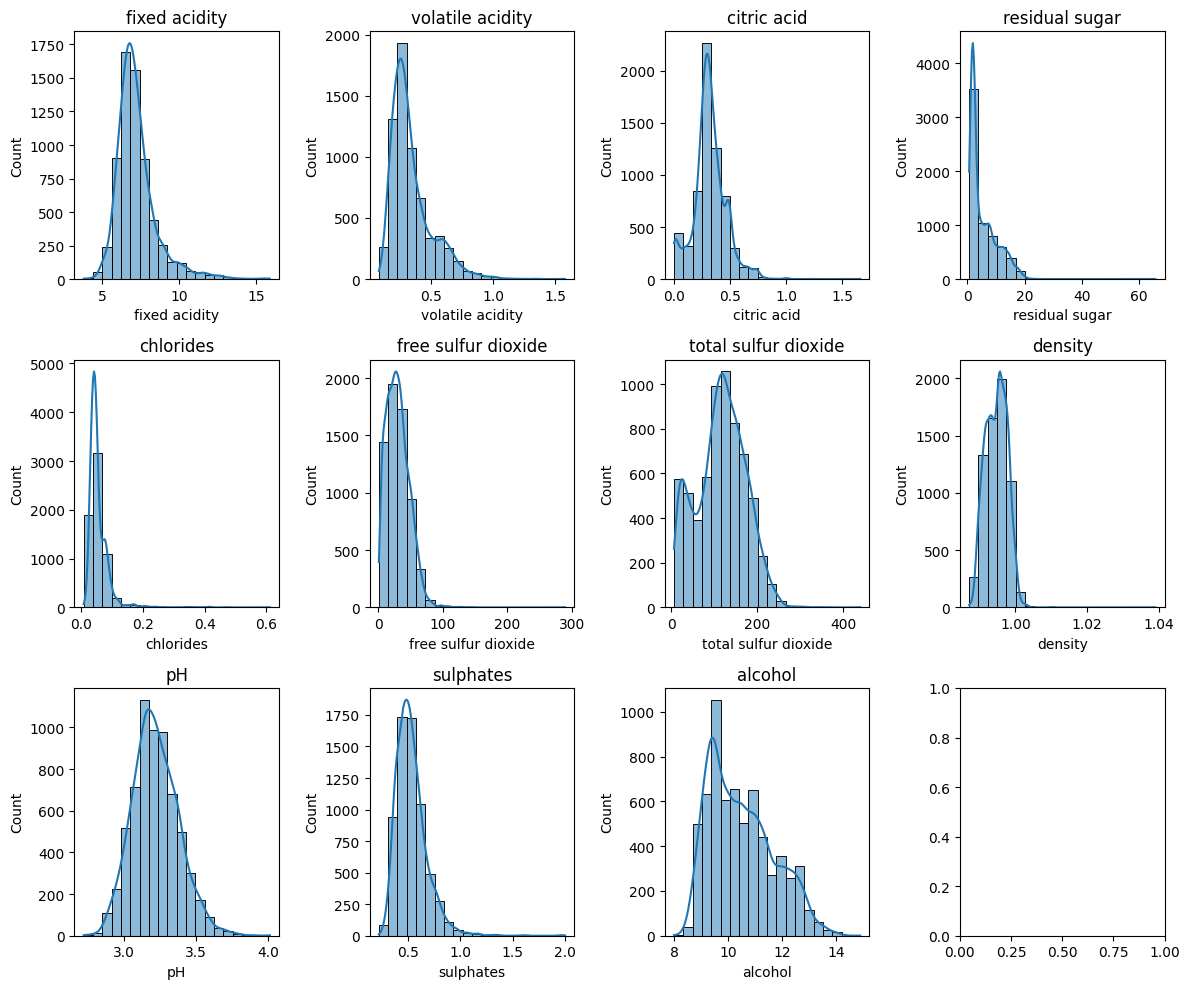

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = wine.drop(columns='quality').select_dtypes(include='number').columns

fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(
        wine[col],
        bins=20,
        kde=True,
        edgecolor='black',
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

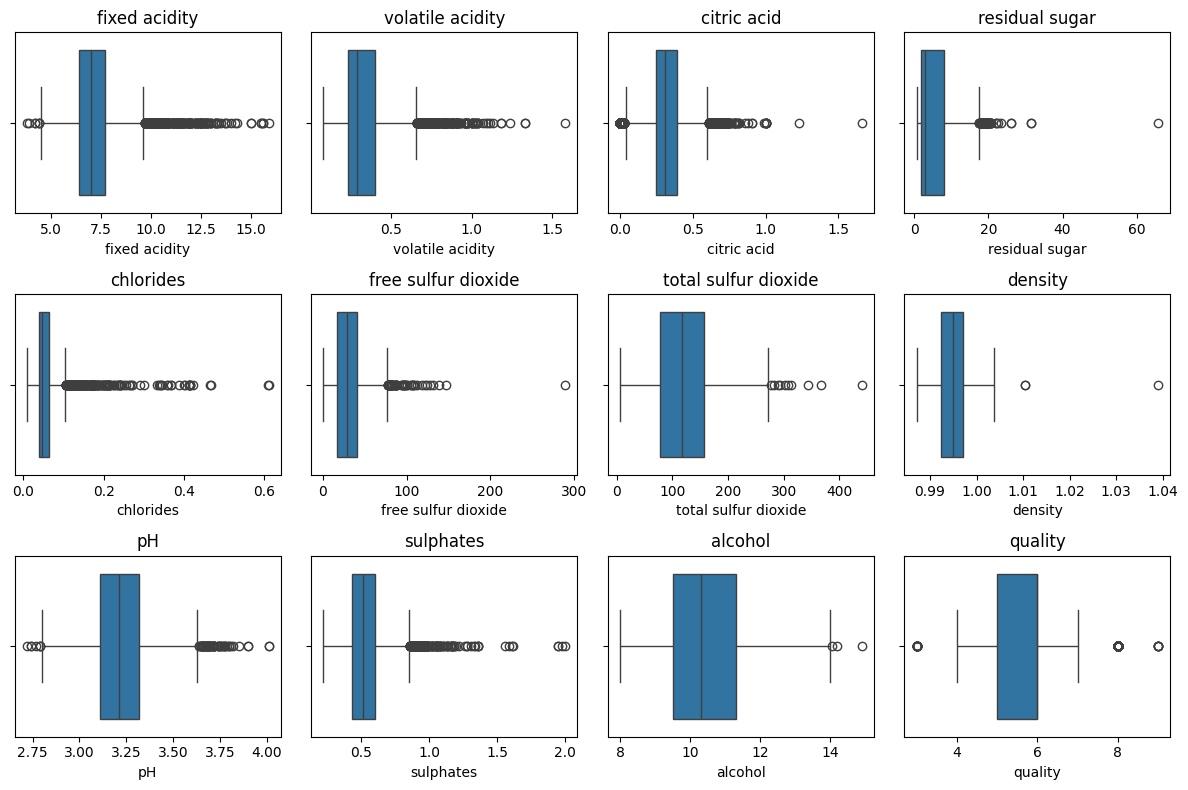

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = wine.select_dtypes(include='number').columns

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=wine[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [190]:
X=wine.iloc[:,1:]
y=wine.iloc[:,0]

In [191]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [192]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [193]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [194]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()

In [195]:
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [196]:
y_pred=KNN.predict(X_test)

In [197]:
from sklearn.metrics import accuracy_score

In [198]:
accuracy_score(y_pred,y_test)

0.9915384615384616

# PCA

In [199]:
from sklearn.decomposition import PCA
pca=PCA(n_components=5)

In [200]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [201]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)

In [202]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [203]:
y_pred1=knn.predict(X_test_trf)

In [204]:
accuracy_score(y_pred1,y_test)

0.9846153846153847